In [142]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


In [115]:
DATA='../../data/brca.csv' 

In [116]:
df = pd.read_csv(DATA)

df.head()

,Unnamed: 0,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,...,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst,y
0,1,13.540,14.36,87.46,566.3,0.09779,0.08129,0.06664,0.047810,0.1885,...,19.26,99.70,711.2,0.14400,0.17730,0.23900,0.12880,0.2977,0.07259,B
1,2,13.080,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.031100,0.1967,...,20.49,96.09,630.5,0.13120,0.27760,0.18900,0.07283,0.3184,0.08183,B
2,3,9.504,12.44,60.34,273.9,0.10240,0.06492,0.02956,0.020760,0.1815,...,15.66,65.13,314.9,0.13240,0.11480,0.08867,0.06227,0.2450,0.07773,B
3,4,13.030,18.42,82.61,523.8,0.08983,0.03766,0.02562,0.029230,0.1467,...,22.81,84.46,545.9,0.09701,0.04619,0.04833,0.05013,0.1987,0.06169,B
4,5,8.196,16.84,51.71,201.9,0.08600,0.05943,0.01588,0.005917,0.1769,...,21.96,57.26,242.2,0.12970,0.13570,0.06880,0.02564,0.3105,0.07409,B


In [117]:
df.head(20)

,Unnamed: 0,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,...,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst,y
0,1,13.540,14.36,87.46,566.3,0.09779,0.08129,0.066640,0.047810,0.1885,...,19.26,99.70,711.2,0.14400,0.17730,0.239000,0.12880,0.2977,0.07259,B
1,2,13.080,15.71,85.63,520.0,0.10750,0.12700,0.045680,0.031100,0.1967,...,20.49,96.09,630.5,0.13120,0.27760,0.189000,0.07283,0.3184,0.08183,B
2,3,9.504,12.44,60.34,273.9,0.10240,0.06492,0.029560,0.020760,0.1815,...,15.66,65.13,314.9,0.13240,0.11480,0.088670,0.06227,0.2450,0.07773,B
3,4,13.030,18.42,82.61,523.8,0.08983,0.03766,0.025620,0.029230,0.1467,...,22.81,84.46,545.9,0.09701,0.04619,0.048330,0.05013,0.1987,0.06169,B
4,5,8.196,16.84,51.71,201.9,0.08600,0.05943,0.015880,0.005917,0.1769,...,21.96,57.26,242.2,0.12970,0.13570,0.068800,0.02564,0.3105,0.07409,B
5,6,12.050,14.63,78.04,449.3,0.10310,0.09092,0.065920,0.027490,0.1675,...,20.70,89.88,582.6,0.14940,0.21560,0.305000,0.06548,0.2747,0.08301,B
6,7,13.490,22.30,86.91,561.0,0.08752,0.07698,0.047510,0.033840,0.1809,...,31.82,99.00,698.8,0.11620,0.17110,0.228200,0.12820,0.2871,0.06917,B
7,8,11.760,21.60,74.72,427.9,0.08637,0.04966,0.016570,0.011150,0.1495,...,25.72,82.98,516.5,0.10850,0.08615,0.055230,0.03715,0.2433,0.06563,B
8,9,13.640,16.34,87.21,571.8,0.07685,0.06059,0.018570,0.017230,0.1353,...,23.19,96.08,656.7,0.10890,0.15820,0.105000,0.08586,0.2346,0.08025,B
9,10,11.940,18.24,75.71,437.6,0.08261,0.04751,0.019720,0.013490,0.1868,...,21.33,83.67,527.2,0.11440,0.08906,0.092030,0.06296,0.2785,0.07408,B


In [118]:
df.drop(columns='Unnamed: 0', inplace=True)

In [119]:
df.head()

,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,x.fractal_dim_mean,...,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst,y
0,13.540,14.36,87.46,566.3,0.09779,0.08129,0.06664,0.047810,0.1885,0.05766,...,19.26,99.70,711.2,0.14400,0.17730,0.23900,0.12880,0.2977,0.07259,B
1,13.080,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.031100,0.1967,0.06811,...,20.49,96.09,630.5,0.13120,0.27760,0.18900,0.07283,0.3184,0.08183,B
2,9.504,12.44,60.34,273.9,0.10240,0.06492,0.02956,0.020760,0.1815,0.06905,...,15.66,65.13,314.9,0.13240,0.11480,0.08867,0.06227,0.2450,0.07773,B
3,13.030,18.42,82.61,523.8,0.08983,0.03766,0.02562,0.029230,0.1467,0.05863,...,22.81,84.46,545.9,0.09701,0.04619,0.04833,0.05013,0.1987,0.06169,B
4,8.196,16.84,51.71,201.9,0.08600,0.05943,0.01588,0.005917,0.1769,0.06503,...,21.96,57.26,242.2,0.12970,0.13570,0.06880,0.02564,0.3105,0.07409,B


In [120]:
summary = df.describe()
print(summary)

       x.radius_mean  x.texture_mean  x.perimeter_mean  x.area_mean  \
count     569.000000      569.000000        569.000000   569.000000   
mean       14.127292       19.289649         91.969033   654.889104   
std         3.524049        4.301036         24.298981   351.914129   
min         6.981000        9.710000         43.790000   143.500000   
25%        11.700000       16.170000         75.170000   420.300000   
50%        13.370000       18.840000         86.240000   551.100000   
75%        15.780000       21.800000        104.100000   782.700000   
max        28.110000       39.280000        188.500000  2501.000000   

       x.smoothness_mean  x.compactness_mean  x.concavity_mean  \
count         569.000000          569.000000        569.000000   
mean            0.096360            0.104341          0.088799   
std             0.014064            0.052813          0.079720   
min             0.052630            0.019380          0.000000   
25%             0.086370      

In [121]:
def display_plots(column, k, title, lable):
    summary.loc[column].plot(kind=k, figsize=(15,5))
    plt.title(title)
    plt.ylabel(lable)
    plt.xticks(rotation=90)
    plt.show()

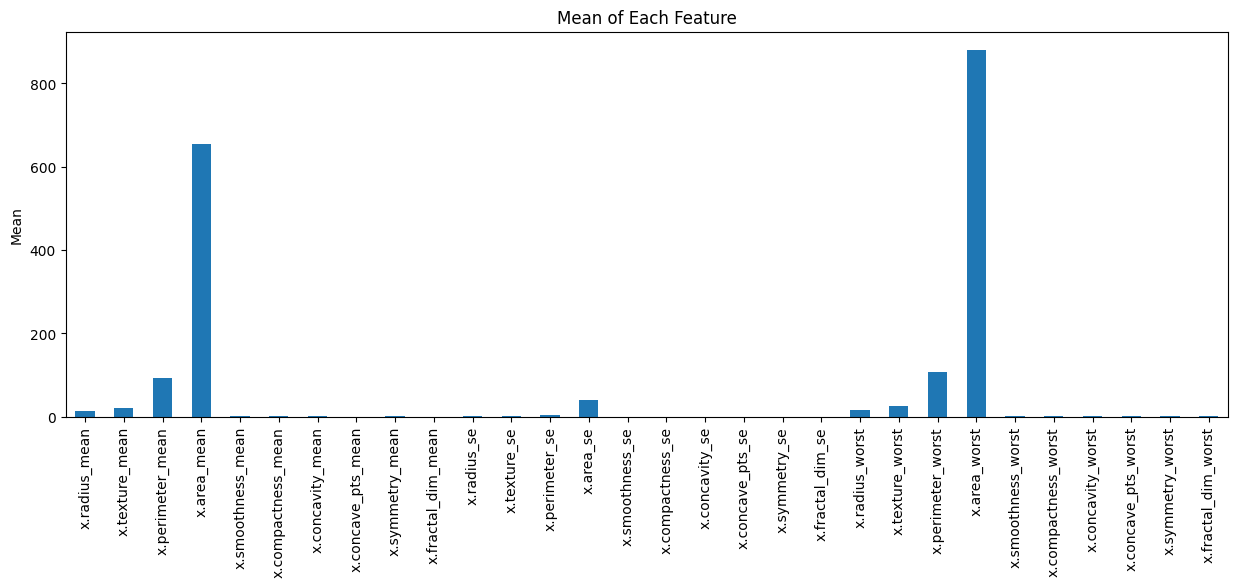

In [122]:
display_plots("mean", "bar", "Mean of Each Feature", "Mean")

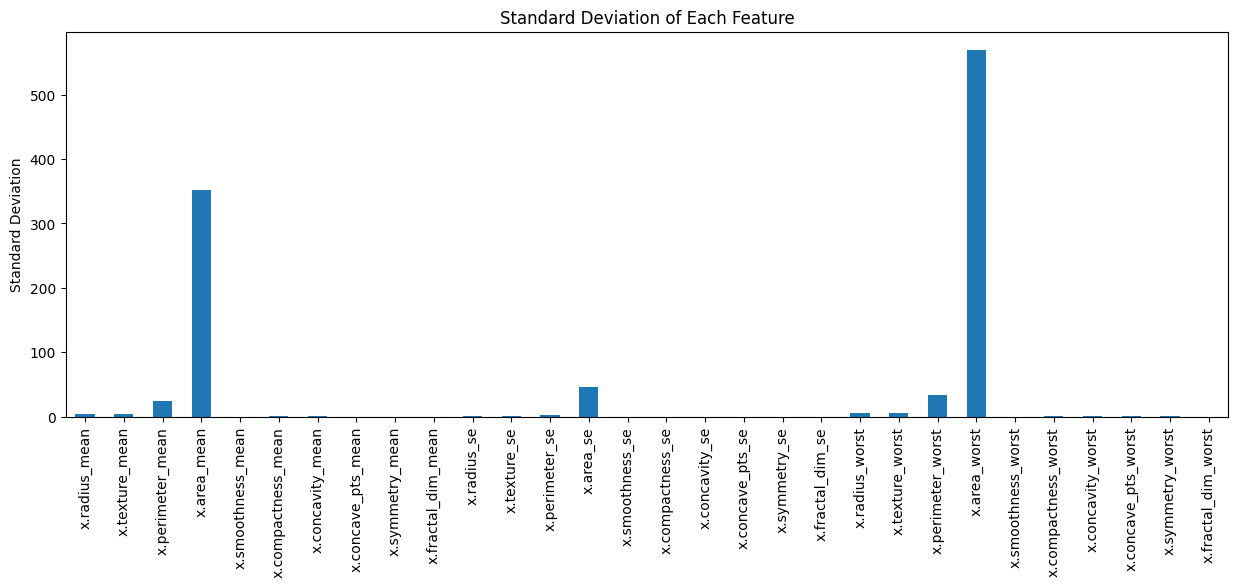

In [123]:
display_plots("std", "bar", "Standard Deviation of Each Feature", "Standard Deviation")

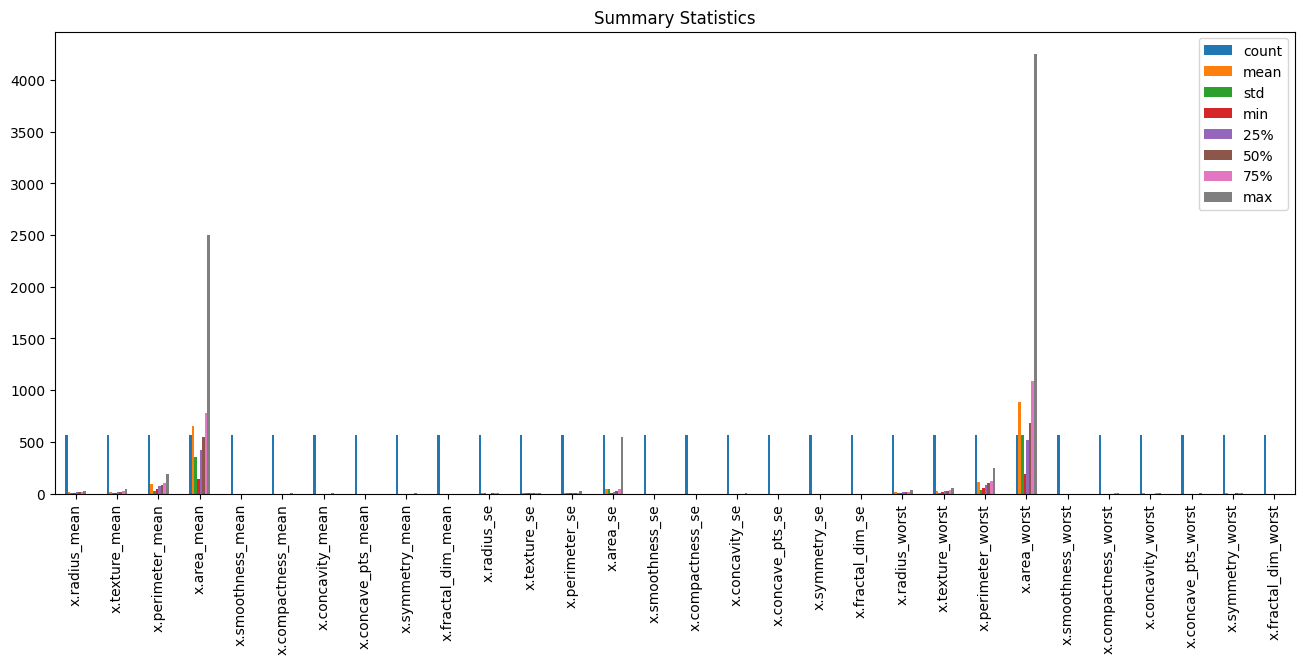

In [124]:
summary.T.plot(kind="bar", figsize=(16,6))
plt.title("Summary Statistics")
plt.xticks(rotation=90)
plt.show()

In [125]:

from sklearn.preprocessing import StandardScaler

# Separate features and target
X = df.drop("y", axis=1)
y = df["y"]

# Create scaler
scaler = StandardScaler()

# Scale all features
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
y = y.map({
    "B": 1,
    "M": 0
})

print(X_scaled.head())

   x.radius_mean  x.texture_mean  x.perimeter_mean  x.area_mean  \
0      -0.166799       -1.147162         -0.185728    -0.251957   
1      -0.297446       -0.833008         -0.261106    -0.383638   
2      -1.313080       -1.593959         -1.302806    -1.083572   
3      -0.311646       -0.202373         -0.385500    -0.372831   
4      -1.684571       -0.570050         -1.658278    -1.288347   

   x.smoothness_mean  x.compactness_mean  x.concavity_mean  \
0           0.101747           -0.436850         -0.278210   
1           0.792763            0.429422         -0.541362   
2           0.429819           -0.747086         -0.743748   
3          -0.464730           -1.263703         -0.793214   
4          -0.737294           -0.851130         -0.915500   

   x.concave_pts_mean  x.symmetry_mean  x.fractal_dim_mean  ...  \
0           -0.028609         0.267911           -0.728310  ...   
1           -0.459627         0.567289            0.753087  ...   
2           -0.726337  

In [126]:
summary = X_scaled.describe()
print(summary)

       x.radius_mean  x.texture_mean  x.perimeter_mean   x.area_mean  \
count   5.690000e+02    5.690000e+02      5.690000e+02  5.690000e+02   
mean   -1.998011e-16   -7.492542e-16     -9.990056e-17 -1.998011e-16   
std     1.000880e+00    1.000880e+00      1.000880e+00  1.000880e+00   
min    -2.029648e+00   -2.229249e+00     -1.984504e+00 -1.454443e+00   
25%    -6.893853e-01   -7.259631e-01     -6.919555e-01 -6.671955e-01   
50%    -2.150816e-01   -1.046362e-01     -2.359800e-01 -2.951869e-01   
75%     4.693926e-01    5.841756e-01      4.996769e-01  3.635073e-01   
max     3.971288e+00    4.651889e+00      3.976130e+00  5.250529e+00   

       x.smoothness_mean  x.compactness_mean  x.concavity_mean  \
count       5.690000e+02        5.690000e+02        569.000000   
mean        1.498508e-16        1.998011e-16          0.000000   
std         1.000880e+00        1.000880e+00          1.000880   
min        -3.112085e+00       -1.610136e+00         -1.114873   
25%        -7.109628e

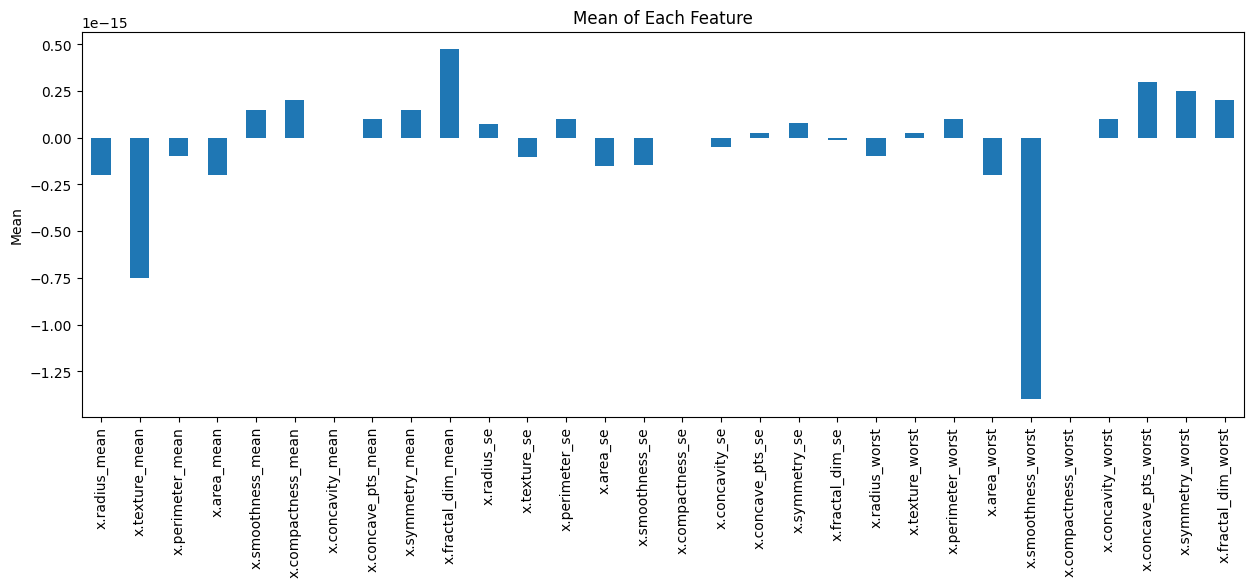

In [127]:
display_plots("mean", "bar", "Mean of Each Feature", "Mean")

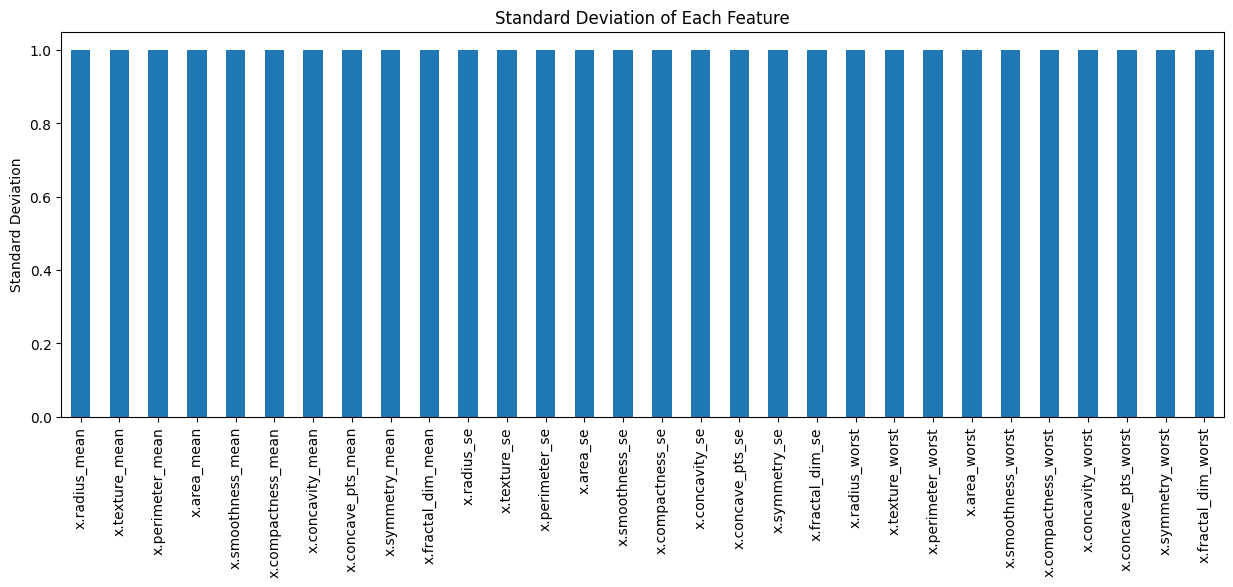

In [128]:
display_plots("std", "bar", "Standard Deviation of Each Feature", "Standard Deviation")

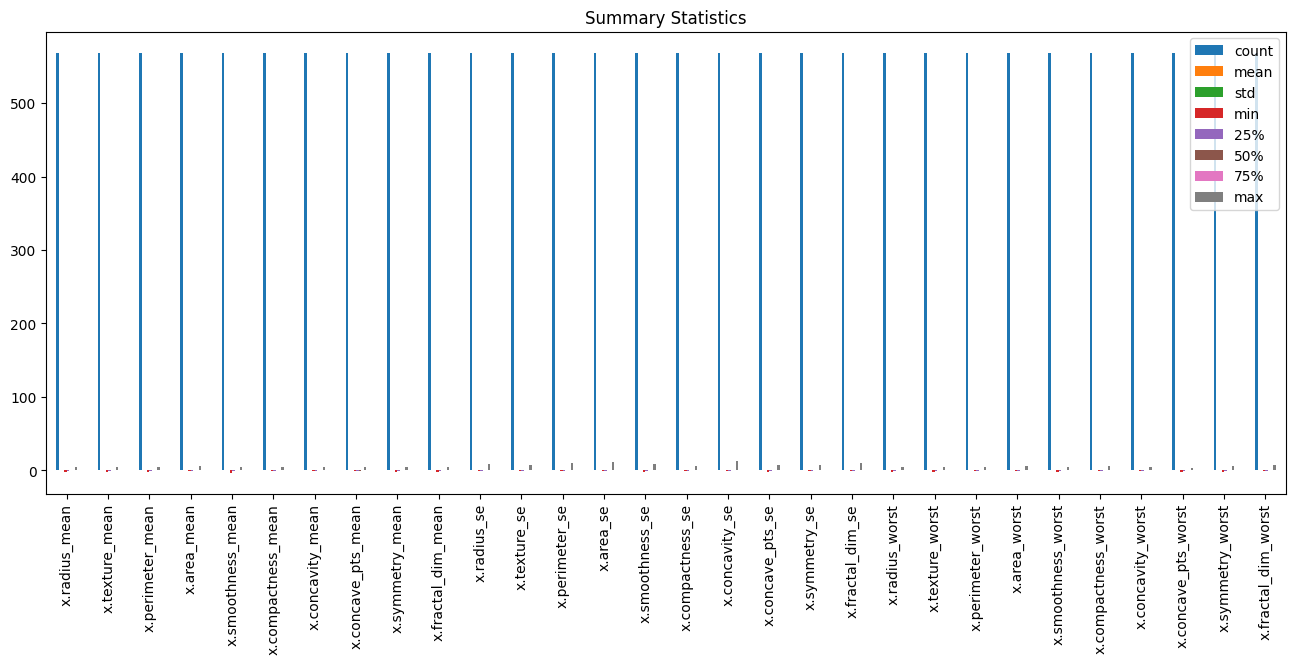

In [129]:
summary.T.plot(kind="bar", figsize=(16,6))
plt.title("Summary Statistics")
plt.xticks(rotation=90)
plt.show()

# Creating a model

In [132]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [133]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [134]:
scaler.fit_transform(X)

array([[-0.16679919, -1.1471623 , -0.18572799, ...,  0.21612292,
         0.12334653, -0.62929189],
       [-0.29744572, -0.83300824, -0.26110605, ..., -0.63610973,
         0.45822712, -0.11724974],
       [-1.31308049, -1.59395919, -1.30280622, ..., -0.7969026 ,
        -0.72922385, -0.34445459],
       ...,
       [ 1.70485436,  2.08513394,  1.61593137, ...,  0.73382724,
        -0.53185462, -0.97397828],
       [ 0.70228425,  2.0455738 ,  0.67267578, ...,  0.41406869,
        -1.10454895, -0.31840916],
       [ 1.83834103,  2.33645719,  1.98252415, ...,  2.28998549,
         1.91908301,  2.21963528]], shape=(569, 30))

In [135]:
model = LogisticRegression()

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [136]:
y_pred = model.predict(X_test)

In [137]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9649122807017544


In [138]:
print(confusion_matrix(y_test, y_pred))

[[41  2]
 [ 2 69]]


In [139]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.95      0.95        43
           1       0.97      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114



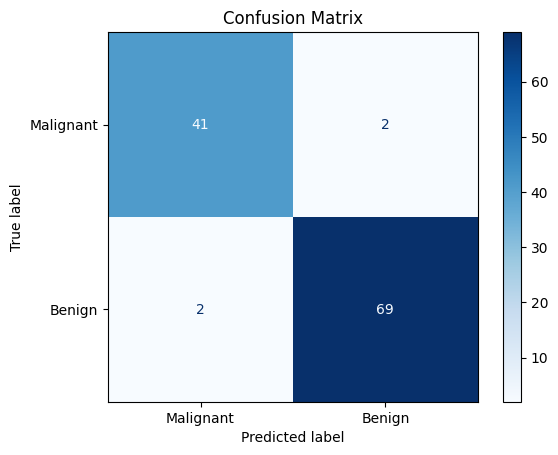

In [141]:


# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["Malignant", "Benign"])

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")
plt.show()

In [143]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE : 0.03508771929824561
MSE : 0.03508771929824561
RMSE: 0.1873171623163388
R² Score: 0.8506387160170324
